## 環境設置

In [1]:
try:
    import openseespy.opensees as ops  # noqa: F401
except ImportError:
    import sys
    !{sys.executable} -m pip install -q openseespy
    import openseespy.opensees as ops  # noqa: F401

import numpy as np
import matplotlib.pyplot as plt

# Case-07.5:轉換斷面 vs 纖維積分——同一件事的兩種算法

這份 notebook 是 Case-07 第 1 課「四方比較」的**理論展開版**,目的
是讓想搞懂「為什麼」的人,能從頭看到轉換斷面公式跟纖維積分方法
到底在算同一件事的哪個部分,不是兩個各自獨立、剛好湊巧數字接近
的方法。

**這裡假設讀者知道材料力學裡「彎曲應力 $\sigma=My/I$」這個公式,
但不假設讀者已經知道轉換斷面法或纖維法怎麼推導。**

## 第 1 課:為什麼混凝土斷面裡有鋼筋,問題就變複雜了

**均質材料的彎曲勁度**很單純:整個斷面只有一種材料,慣性矩 $I$
只跟幾何形狀有關,彎曲勁度就是 $EI$,$E$ 是這個材料的彈性模數。

**鋼筋混凝土不是均質材料**——同一個斷面裡有混凝土(承壓為主)跟
鋼筋(承拉為主),兩者彈性模數差了將近 10 倍($E_s\approx200000$MPa,
$E_c\approx25000$MPa 左右)。如果直接把鋼筋的「面積」跟混凝土的
「面積」加在一起算幾何慣性矩,是錯的——因為同樣的應變下,鋼筋能
扛的應力是混凝土的 8~10 倍,不能只看面積不看材料。

**這就是轉換斷面法要解決的問題**:把「不同材料」的複合斷面,轉換
成一個「假想的、只有單一材料」的等效斷面,讓材料力學那套簡單公式
可以繼續用。

## 第 2 課:轉換斷面法——古典解析解

**核心想法**:選一個「參考材料」(通常選混凝土),把鋼筋的面積
依照模數比 $n=E_s/E_c$ 放大,變成「假想的、用混凝土做的」等效
面積:

$$A_{s,tr} = n \cdot A_s$$

**為什麼可以這樣轉換**:平截面假設下,同一個位置的應變 $\varepsilon$
對混凝土跟鋼筋是一樣的(兩者黏結在一起變形)。應力 $\sigma=E\varepsilon$,
所以同樣應變下鋼筋應力是混凝土的 $n$ 倍。如果把鋼筋"畫成"用混凝土
做的,但面積放大 $n$ 倍,兩者在同一個應變下產生的**合力**($\sigma
\times A$)會相等——這就是「等效」的意思:內力相等,不是材料真的
變成同一種。

**算出轉換後的慣性矩**(對於對稱配筋、形心不偏移的情況,直接用
平行軸定理疊加):

$$I_{tr} = I_c + \sum n \cdot A_{s,i} \cdot d_i^2$$

$I_c$ 是純混凝土斷面對形心的慣性矩,$d_i$ 是第 $i$ 根鋼筋到形心的
距離。**乘上參考材料的 $E_c$,就是轉換斷面的抗彎勁度**:

$$EI_{tr} = E_c \cdot I_{tr} = E_c I_c + \sum E_c \cdot n \cdot A_{s,i} d_i^2
= E_c I_c + \sum E_s A_{s,i} d_i^2$$

(因為 $E_c \cdot n = E_c \cdot (E_s/E_c) = E_s$,模數比在這一步
自然消掉,只留下 $E_s$ 本身。)

In [2]:
# 我們的柱斷面參數(沿用Case-06/07)
b = h = 0.40
cover = 0.04
fc = 27.46e3      # kN/m^2
fy = 411.88e3     # kN/m^2
Es = 2.0e8        # kN/m^2
rho = 0.02
As_total = rho*b*h
As_bar = As_total/8

half = h/2
core_half = h/2 - cover
positions = [(-core_half,-core_half),(core_half,-core_half),(core_half,core_half),(-core_half,core_half),
             (0,-core_half),(0,core_half),(-core_half,0),(core_half,0)]

# 這裡先用最單純的版本示範轉換斷面法: 整個斷面只用一種混凝土(不分核心/保護層)
E_c_simple = 2*fc/0.002   # Concrete01在原點附近的切線模數
n_ratio = Es/E_c_simple
print(f"模數比 n = Es/Ec = {n_ratio:.2f}")

Ic_gross = h**4/12   # 純混凝土斷面(不扣鋼筋佔的面積, 這裡簡化不扣, 因為鋼筋佔比小)
I_steel_transformed = sum(n_ratio*As_bar*y**2 for y,z in positions)
I_tr = Ic_gross + I_steel_transformed
EI_tr_simple = E_c_simple*I_tr

print(f"\nIc(純混凝土毛斷面) = {Ic_gross:.6f} m^4")
print(f"轉換後鋼筋貢獻 n x sum(As x d^2) = {I_steel_transformed:.6f} m^4")
print(f"I_tr(轉換斷面總慣性矩) = {I_tr:.6f} m^4")
print(f"EI_tr = Ec x I_tr = {EI_tr_simple:.2f} kN-m^2")

模數比 n = Es/Ec = 7.28

Ic(純混凝土毛斷面) = 0.002133 m^4
轉換後鋼筋貢獻 n x sum(As x d^2) = 0.000447 m^4
I_tr(轉換斷面總慣性矩) = 0.002581 m^4
EI_tr = Ec x I_tr = 70869.33 kN-m^2


## 第 3 課:纖維積分法——數值解

**核心想法完全不同,但殊途同歸**:纖維法不轉換材料,而是把整個
斷面切成很多個小面積(纖維),**每根纖維保留自己真正的材料**——
混凝土纖維用混凝土的 $E$,鋼筋纖維用鋼筋的 $E$,分開處理,最後
直接對每根纖維做積分:

$$EI_{fiber} = \sum_i E_i \cdot A_i \cdot y_i^2$$

$E_i$ 是第 $i$ 根纖維的材料模數(混凝土纖維用 $E_c$,鋼筋纖維用
$E_s$),$A_i$ 是這根纖維的面積,$y_i$ 是這根纖維到形心的距離。

**這個式子跟第 2 課轉換斷面最後那條式子,其實是同一個東西**:

$$EI_{tr} = E_c I_c + \sum E_s A_{s,i} d_i^2
\quad\Longleftrightarrow\quad
EI_{fiber} = \sum_{\text{混凝土纖維}} E_c A_i y_i^2 + \sum_{\text{鋼筋纖維}} E_s A_{s,i} d_i^2$$

左邊第一項 $E_c I_c$ 其實就是「把混凝土斷面本身也切成無限多根纖維,
對每根纖維積分」的解析解——**轉換斷面法對混凝土部分直接用解析解
$I_c$,對鋼筋部分手動疊加;纖維法對兩者都用同一套數值積分,不特別
處理**。纖維切得夠細,數值積分就會收斂到解析解,這就是為什麼
Case-07 第 1.6 課的收斂測試,纖維法的答案會逼近轉換斷面的答案。

In [3]:
def build_fiber_section_simple(n_div):
    """最單純的版本: 整個斷面只用一種混凝土, 不分核心/保護層,
    才能跟第2課的簡化轉換斷面公平比較(同一組材料假設)"""
    ops.wipe()
    ops.model('basic','-ndm',2,'-ndf',3)
    ops.uniaxialMaterial('Concrete01', 1, -fc, -0.002, -0.2*fc, -0.006)
    ops.uniaxialMaterial('Steel02', 2, fy, Es, 0.01, 18, 0.925, 0.15)
    ops.section('Fiber', 1)
    ops.patch('rect', 1, n_div, n_div, -half, -half, half, half)
    for (y,z) in positions:
        ops.fiber(y, z, As_bar, 2)


def query_EI(n_div):
    build_fiber_section_simple(n_div)
    ops.node(1,0.0,0.0); ops.node(2,0.0,0.0)
    ops.fix(1,1,1,1); ops.fix(2,0,1,0)
    ops.element('zeroLengthSection',1,1,2,1)
    ops.system('BandGeneral'); ops.numberer('Plain'); ops.constraints('Plain')
    ops.test('NormUnbalance',1e-10,30); ops.algorithm('Newton')
    ops.integrator('LoadControl', 1.0); ops.analysis('Static')
    k = ops.eleResponse(1, 'section', 'stiffness')
    return k[3]


print(f"{'n_div':<10}{'EI_fiber':<15}{'與轉換斷面解析解差異'}")
n_list = [4, 10, 20, 40]
EI_list = []
for n in n_list:
    EI_n = query_EI(n)
    EI_list.append(EI_n)
    diff = abs(EI_n-EI_tr_simple)/EI_tr_simple
    print(f"{n:<10}{EI_n:<15.2f}{diff:.3%}")

assert abs(EI_list[-1]-EI_tr_simple)/EI_tr_simple < 0.01, "n_div=40時纖維法應與轉換斷面解析解相差在1%內"
print("\n[PASS] 纖維積分法收斂到轉換斷面解析解, 驗證兩者是同一件事的兩種算法")

n_div     EI_fiber       與轉換斷面解析解差異
4         67208.00       5.166%
10        70283.52       0.827%
20        70722.88       0.207%
40        70832.72       0.052%

[PASS] 纖維積分法收斂到轉換斷面解析解, 驗證兩者是同一件事的兩種算法


## 第 4 課:視覺化——收斂過程

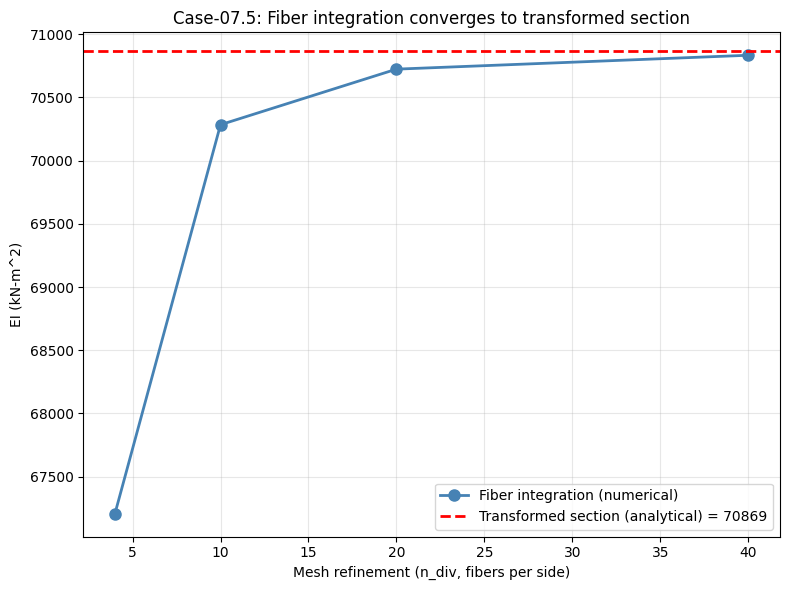

In [4]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(n_list, EI_list, 'o-', color='steelblue', lw=2, ms=8, label='Fiber integration (numerical)')
ax.axhline(EI_tr_simple, color='red', ls='--', lw=2, label=f'Transformed section (analytical) = {EI_tr_simple:.0f}')
ax.set_xlabel('Mesh refinement (n_div, fibers per side)')
ax.set_ylabel('EI (kN-m^2)')
ax.set_title('Case-07.5: Fiber integration converges to transformed section')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 第 5 課:兩種方法的取捨——為什麼不是全部都用轉換斷面就好

既然轉換斷面法是解析解、不需要數值收斂,為什麼 Case-06 全程都用
纖維法,不乾脆都用轉換斷面法?

**轉換斷面法的前提是材料保持線彈性**(應力應變關係是一直線)。一旦
材料進入非線性(混凝土開始壓碎、鋼筋開始降伏),「模數比 $n$」這個
概念就失效了——$n=E_s/E_c$ 假設兩者都還在各自的彈性直線段,材料
一旦降伏,$E$ 本身就不再是常數,轉換斷面公式沒辦法繼續套用。

**這正是 Case-06 全程要用纖維法的原因**:纖維法在每一步都個別追蹤
每根纖維目前所在的應力應變曲線位置(不管是彈性段還是降伏後的段),
不需要假設整體行為維持線性。轉換斷面法只在**未開裂、未降伏的初始
彈性狀態**這個特例下,才會跟纖維法給出一樣的答案——這正是 Case-07
拿它們互相驗證(而不是拿它們互相取代)的原因。

## 總結表

In [5]:
print("="*55)
print("Case-07.5 理論總結")
print("="*55)
print(f"{'轉換斷面(解析解)':<24}{EI_tr_simple:.2f} kN-m^2")
print(f"{'纖維積分(n_div=40)':<24}{EI_list[-1]:.2f} kN-m^2")
print(f"{'差異':<24}{abs(EI_list[-1]-EI_tr_simple)/EI_tr_simple:.3%}")
print()
print("結論: 線彈性、未開裂、平截面假設下, 轉換斷面法與纖維積分法")
print("是同一件事的兩種算法——前者是解析解(材料仍在彈性段時的捷徑),")
print("後者是數值解(材料進入非線性後唯一還能用的方法)。")
print()
print("Case-07.5 [PASS] -- 理論對照完成")

Case-07.5 理論總結
轉換斷面(解析解)               70869.33 kN-m^2
纖維積分(n_div=40)          70832.72 kN-m^2
差異                      0.052%

結論: 線彈性、未開裂、平截面假設下, 轉換斷面法與纖維積分法
是同一件事的兩種算法——前者是解析解(材料仍在彈性段時的捷徑),
後者是數值解(材料進入非線性後唯一還能用的方法)。

Case-07.5 [PASS] -- 理論對照完成
